# 2D FEM Solver

We aim to solve the differential linear equation

\begin{equation}
-\frac{\partial}{\partial x}\left(\alpha_1(x, y) \frac{\partial \Phi(x, y)}{\partial x}\right)-\frac{\partial}{\partial y}\left(\alpha_2(x, y) \frac{\partial \Phi(x, y)}{\partial y}\right)+\beta(x, y) \Phi(x, y)=f(x, y)
\end{equation}

on the area given by the following image.

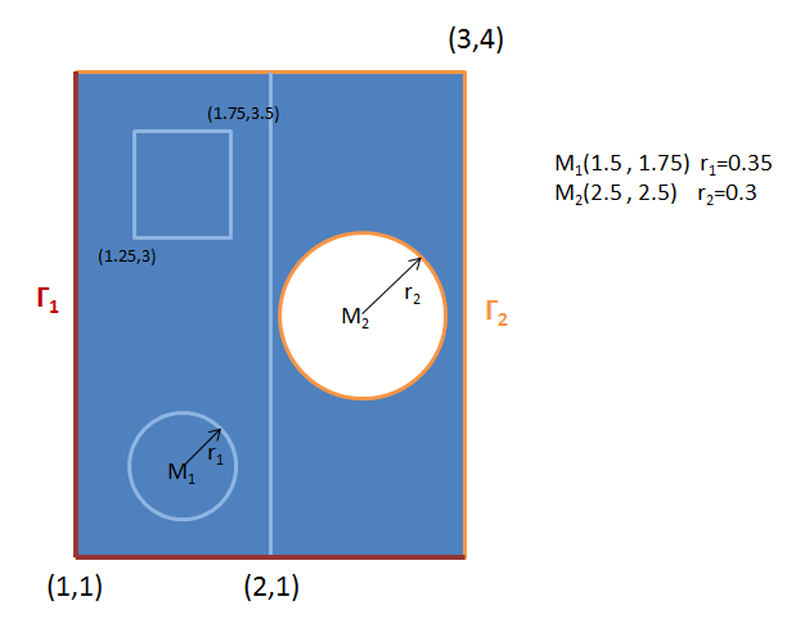

## Dirichtlet

\begin{equation}
\Phi(x, y) = x^2 -y^2 +1 \quad x,y \in \Gamma_1
\end{equation}

In [2]:
import numpy as np

import functions as myfunc

## Assign Parameters from Task

In [3]:
DOMAIN_KNOTS = np.loadtxt("Lösung/Netz2D_p.dat")
ELEMENTS = np.loadtxt("Lösung/Netz2D_t.dat", dtype=int) # ! dtype is important here.


def alpha1(x, y):
    """
    Piecewise function for alpha1(x, y):
    - 0.01 for (x, y) in rectangle [1.25, 1.75] x [3, 3.5]
    - 5 * y * x^2 elsewhere
    """
    x = np.asarray(x)
    y = np.asarray(y)
    mask = (1.25 <= x) & (x <= 1.75) & (3 <= y) & (y <= 3.5)
    return np.where(mask, 0.01, 5 * y * np.square(x))
    
def alpha2(x, y):
    return np.power(y, 2)

def beta(x, y):
    """
    Piecewise function for beta(x, y):
    - 500 inside circle with radius 0.35 centered at (1.5, 1.75)
    - 5 elsewhere
    """
    x = np.asarray(x)
    y = np.asarray(y)
    dist_sq = np.square(x - 1.5) + np.square(y - 1.75)
    mask = dist_sq <= 0.35**2
    return np.where(mask, 500, 5)

def rhs(x, y):
    """
    Piecewise function for rhs(x, y):
    - -10 * x * y where x >= 2
    - 0 elsewhere
    """
    x = np.asarray(x)
    y = np.asarray(y)
    mask = x >= 2
    return np.where(mask, -10 * x * y, 0)
    
# Dirichlet Boundary Conditions
DIRICHLET_INDICES = np.loadtxt("Lösung/Netz2D_dr_a).dat", dtype=int)
def dirichlet(x, y):
    return np.power(x, 2) - np.power(y, 2) + 1

## My Work

In [4]:
number_of_elements = myfunc.get_number_of_elements(ELEMENTS)
print(f"Number of elements: {number_of_elements}")

Number of elements: 2400


In [5]:
stiffness_matrix, load_vector = myfunc.assemble_global_system(DOMAIN_KNOTS, ELEMENTS, alpha1, alpha2, beta, rhs)

In [6]:
stiffness_matrix, load_vector = myfunc.insert_dirichlet_values(DOMAIN_KNOTS, stiffness_matrix, load_vector, DIRICHLET_INDICES, dirichlet)

In [7]:
own_solution = myfunc.solve_system(DOMAIN_KNOTS, stiffness_matrix, load_vector)

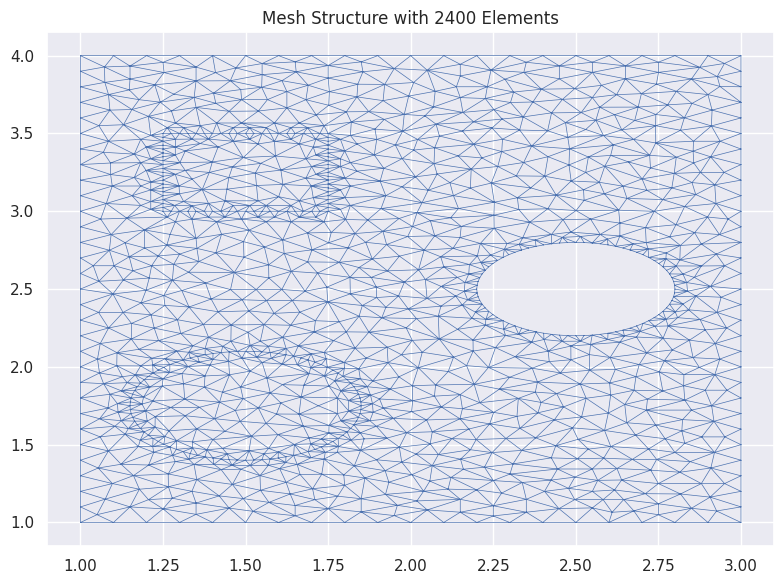

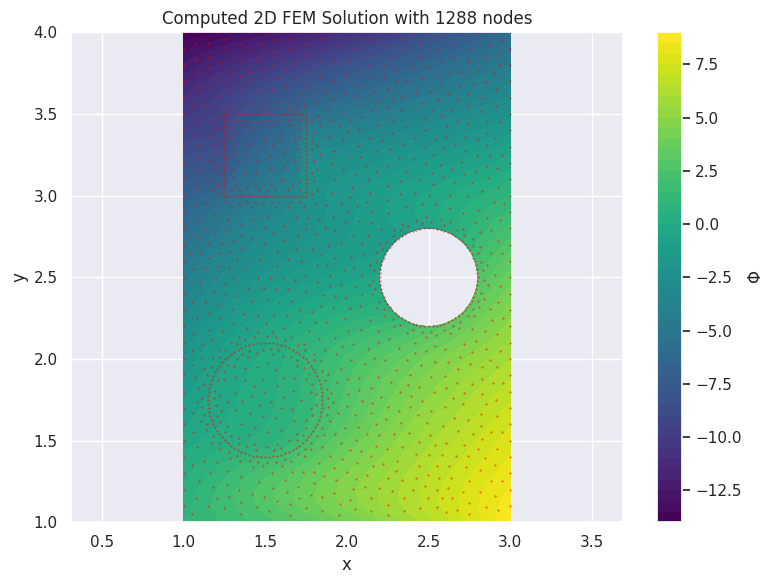

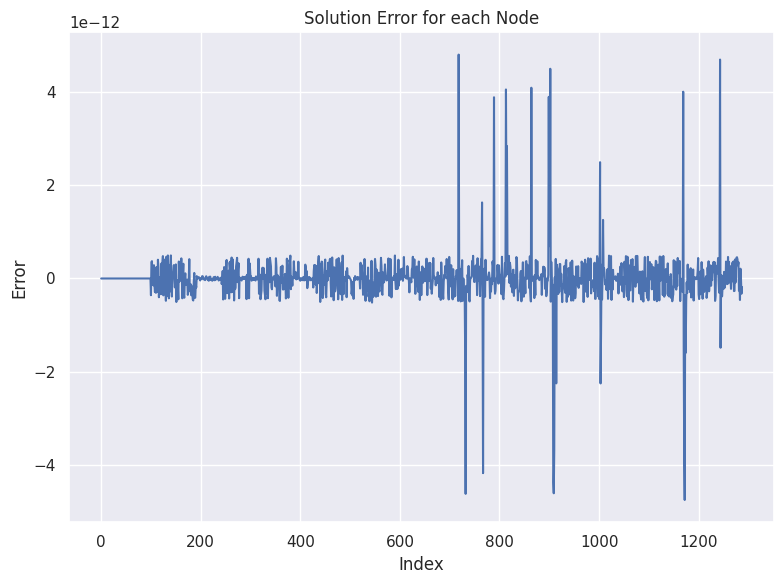

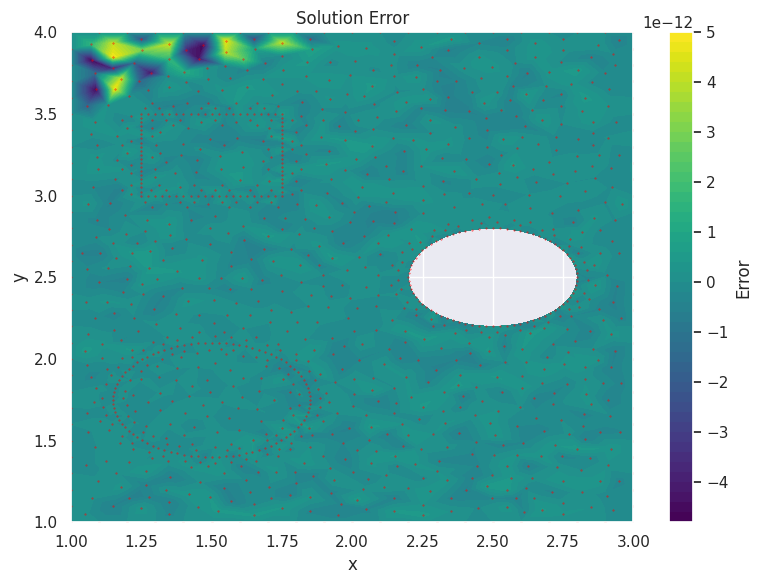

In [8]:
myfunc.plot_result(ELEMENTS, own_solution, "Lösung/Netz2D_LoesungA.dat", levels=50, knots=DOMAIN_KNOTS)